<a href="https://colab.research.google.com/github/aadi-9/Skin-cancer-detection/blob/main/Skin_Cancer_Detector(v2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from google.colab import files
# files.upload() # Select the kaggle.json file

In [ ]:
# # Set up the Kaggle API key
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# # Create a project folder in your Google Drive
# !mkdir -p /content/drive/MyDrive/SkinCancerProject
# %cd /content/drive/MyDrive/SkinCancerProject

# # Download the dataset directly into the current directory (your project folder)
# # This might take a few minutes.
# !kaggle competitions download -c isic-2019-skin-cancer-classification

# print("✅ Dataset downloaded to your Google Drive!")

In [ ]:
# # The project folder is our current directory
# # Unzip the main competition file
# !unzip -q archive.zip

# # Unzip the training images into a 'data' subfolder
# !mkdir -p data
# !unzip -q archive.zip -d data/

# print("✅ All files are unzipped and ready in your Google Drive!")

In [ ]:
# ==============================================================================
# STEP 1: SETUP AND IMPORTS
# ==============================================================================
print("--- Step 1: Setting up environment ---")

# Install the PyTorch Image Models library
!pip install timm -q

# Import necessary libraries
import os
import shutil
import random
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# # ==============================================================================
# # STEP 2: DATA PREPARATION (Splitting and Loading)
# # ==============================================================================
print("--- Step 2: Preparing data loaders for MEL class ---")

# Define paths
original_mel_dir = '/content/drive/MyDrive/SkinCancerProject/data/MEL/'
NEW_DATA_ROOT = '/content/drive/MyDrive/SkinCancerProject/MEL_split_data/'
new_train_mel_dir = os.path.join(NEW_DATA_ROOT, 'train', 'MEL')
new_val_mel_dir = os.path.join(NEW_DATA_ROOT, 'val', 'MEL')
VAL_SPLIT_RATIO = 0.2

# <<< CHANGE START: More efficient data preparation >>>
# Check if data has already been split to avoid re-copying on every run
if os.path.exists(new_train_mel_dir) and os.path.exists(new_val_mel_dir) and len(os.listdir(new_train_mel_dir)) > 0 and len(os.listdir(new_val_mel_dir)) > 0:
    print("--- Split data directories already exist and are not empty. Skipping splitting and copying. ---")
else:
    print("--- Starting dataset splitting and copying ---")
    os.makedirs(new_train_mel_dir, exist_ok=True)
    os.makedirs(new_val_mel_dir, exist_ok=True)

    images_original = [f for f in os.listdir(original_mel_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg')) and os.path.isfile(os.path.join(original_mel_dir, f))]

    if not images_original:
        raise FileNotFoundError(f"No images found in the original MEL directory: {original_mel_dir}. Halting execution.")

    train_images, val_images = train_test_split(images_original, test_size=VAL_SPLIT_RATIO, random_state=42)
    print(f"Splitting {len(images_original)} images into {len(train_images)} train and {len(val_images)} val images.")

    # Copy images
    for img_name in tqdm(train_images, desc="Copying train images"):
        shutil.copy(os.path.join(original_mel_dir, img_name), os.path.join(new_train_mel_dir, img_name))
    for img_name in tqdm(val_images, desc="Copying val images"):
        shutil.copy(os.path.join(original_mel_dir, img_name), os.path.join(new_val_mel_dir, img_name))
    print("--- Dataset splitting and copying complete ---")
# <<< CHANGE END >>>

# Define transformations
IMG_SIZE = 300
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets and dataloaders
train_dataset = datasets.ImageFolder(root=os.path.join(NEW_DATA_ROOT, 'train'), transform=train_transform)
val_dataset = datasets.ImageFolder(root=os.path.join(NEW_DATA_ROOT, 'val'), transform=val_transform)

class_names = train_dataset.classes
num_classes_determined = len(class_names)

print(f"Found {len(train_dataset)} images in the training set.")
print(f"Found {len(val_dataset)} images in the validation set.")
print(f"Classes discovered: {class_names}\n")

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# ==============================================================================
# STEP 3: DEFINE THE MODEL
# ==============================================================================
print("--- Step 3: Defining the Model ---")

# --- Fix: Define num_classes_determined before model creation ---
# Assuming a single-class scenario based on previous user instruction to focus on MEL
# Note: For binary classification (MEL vs NotMEL), this should be 2, and your dataset
# needs to include data from both classes.
num_classes_determined = 1
class_names = ['MEL'] # Define class names for consistency, assuming a single class

# Check if data loaders exist from a previous run of the data preparation cell
if 'train_loader' not in locals() or 'val_loader' not in locals() or 'class_names' not in locals() or 'num_classes_determined' not in locals() or 'val_transform' not in locals() or 'NEW_DATA_ROOT' not in locals():
    print("WARNING: Data preparation variables not found. Model training and inference will be skipped.")
    skip_training = True
    skip_inference = True
else:
     # If data variables exist, update num_classes_determined and class_names based on data prep output
     num_classes_determined = len(class_names)
     print(f"Data preparation variables found. Using num_classes_determined = {num_classes_determined} and class_names = {class_names}")
     skip_training = False
     skip_inference = False


if not skip_training:
    class SimpleClassifier(nn.Module):
        def __init__(self, num_classes):
            super(SimpleClassifier, self).__init__()
            self.backbone = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)
            # Freeze some initial layers of the CNN
            for param in list(self.backbone.parameters())[:100]:
                 param.requires_grad = False
            self.classifier = nn.Linear(self.backbone.num_features, num_classes)

        def forward(self, x):
            features = self.backbone(x)
            output = self.classifier(features)
            return output

    model = SimpleClassifier(num_classes=num_classes_determined).to(device)
    print(f"Model created with {num_classes_determined} output class(es) and moved to device.\n")
else:
    model = None
    print("Model not created because data preparation variables are missing.\n")


# ==============================================================================
# STEP 4: TRAIN THE MODEL
# ==============================================================================
print("--- Step 4: Starting model training ---")

if not skip_training and model and train_loader and val_loader:
    # --- Training Configuration ---
    EPOCHS = 10
    LEARNING_RATE = 1e-4
    MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_single_class_efficientnetb3_best.pth'

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    # For single-class output with num_classes=1, BCEWithLogitsLoss is more appropriate.
    # However, if ImageFolder is used with a single class subfolder, it assigns target label 0.
    # CrossEntropyLoss with num_classes=1 and target 0 can work but is unconventional.
    # Let's stick to CrossEntropyLoss for now, assuming the target labels are 0 from ImageFolder.
    # Note: For true binary classification (MEL vs NotMEL), use num_classes=2 and CrossEntropyLoss,
    # or num_classes=1 and BCEWithLogitsLoss with target labels 0 and 1.
    criterion = nn.CrossEntropyLoss()
    scaler = GradScaler()
    best_val_accuracy = 0.0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0.0
        progress_bar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")
        for inputs, labels in progress_bar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
            progress_bar_train.set_postfix(loss=f"{train_loss / (progress_bar_train.n + 1):.4f}")

        # --- Validation Loop (for model saving) ---
        model.eval()
        val_loss = 0.0
        correct_predictions = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                correct_predictions += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        epoch_val_accuracy = correct_predictions / len(val_dataset) if len(val_dataset) > 0 else 0 # Handle empty val_dataset

        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_val_accuracy:.4f}")

        if epoch_val_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_val_accuracy
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"Validation accuracy improved. Saving model to {MODEL_PATH}")

    print("\n--- Training finished. Best model saved at {MODEL_PATH} ---")


else:
    print("Skipping training as data or model is not ready.")
    skip_inference = True # Skip inference if training was skipped


# ==============================================================================
# STEP 5: FINAL EVALUATION ON VALIDATION SET (with Confusion Matrix)
# ==============================================================================
print("\n--- Step 5: Evaluating the best model on the validation set ---")

if not skip_inference and 'val_loader' in locals() and val_loader and 'class_names' in locals() and class_names and 'num_classes_determined' in locals() and num_classes_determined > 0:
    # Load the best performing model for a final, clean evaluation
    eval_model = SimpleClassifier(num_classes=num_classes_determined)
    if os.path.exists(MODEL_PATH):
        eval_model.load_state_dict(torch.load(MODEL_PATH))
        eval_model.to(device)
        eval_model.eval()
        print("Best model loaded for final evaluation.")

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc="Final Evaluation"):
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast():
                    outputs = eval_model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # --- Generate and Display Metrics ---
        print("\n--- Final Validation Metrics (from best saved model) ---")
        # Ensure class_names list is correct for the labels present in the validation set
        # If only MEL data is loaded, only label 0 will be present.
        # If training on a single class, the classification report and confusion matrix
        # will only show results for that single class.
        print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(cmap=plt.cm.Blues)
        plt.title('Confusion Matrix (Validation Set)')
        plt.show()
    else:
         print(f"Best model weights not found at {MODEL_PATH}. Skipping final evaluation.")
else:
    print("Skipping final evaluation as data or model is not ready or class names are missing.")


# ==============================================================================
# STEP 6: INFERENCE ON A SAMPLE IMAGE
# ==============================================================================
print("\n--- Step 6: Running inference on a sample image ---")

if not skip_inference and 'val_transform' in locals() and 'class_names' in locals() and class_names and 'NEW_DATA_ROOT' in locals() and os.path.exists(MODEL_PATH):
    # The inference model is the same as the evaluation model, which is already loaded
    # If the evaluation step was skipped, load the model weights here
    if 'eval_model' in locals():
         inference_model = eval_model
    else:
         inference_model = SimpleClassifier(num_classes=num_classes_determined)
         if os.path.exists(MODEL_PATH):
             inference_model.load_state_dict(torch.load(MODEL_PATH))
             inference_model.to(device)
             inference_model.eval()
             print("Model loaded for inference.")
         else:
             print(f"Model weights not found at {MODEL_PATH}. Skipping inference.")
             inference_model = None # Ensure inference_model is None if weights not found


    if inference_model:
        sample_dir_to_search = os.path.join(NEW_DATA_ROOT, 'val', 'MEL')
        sample_image_path = None

        if os.path.exists(sample_dir_to_search):
            image_files = [f for f in os.listdir(sample_dir_to_search) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            if image_files:
                # Pick a random sample image from the validation set
                sample_image_path = os.path.join(sample_dir_to_search, random.choice(image_files))
                print(f"Automatically selected sample image: {sample_image_path}")

        if sample_image_path:
            try:
                image = Image.open(sample_image_path).convert("RGB")
                input_tensor = val_transform(image)
                input_batch = input_tensor.unsqueeze(0).to(device)

                with torch.no_grad():
                    output = inference_model(input_batch)
                    probabilities = torch.nn.functional.softmax(output[0], dim=0)
                    # Get top prediction
                    top_prob, top_catid = torch.topk(probabilities, 1)

                idx_to_class = {i: class_name for i, class_name in enumerate(class_names)}

                plt.figure(figsize=(8, 6))
                plt.imshow(image)
                plt.axis('off')
                output_text = f"Prediction: {idx_to_class[top_catid[0].item()]} ({top_prob[0].item()*100:.2f}%)"
                plt.title(output_text, size=14)
                plt.show()

            except FileNotFoundError:
                print(f"\nERROR: Image not found at path: {sample_image_path}")
                print("Please update the 'sample_image_path' variable to a valid image file.")
            except Exception as e:
                print(f"\nAn error occurred during inference: {e}")
        else:
            print("Could not find a sample image in the validation directory. Skipping inference.")

    # else: # This else is associated with the 'if inference_model:' block above
    #     # Message already printed inside the block if weights were not found
    pass # Placeholder if no model is loaded


else:
    print("Skipping inference as data or model is not ready, class names are missing, or model weights are not found.")

--- Step 1: Setting up environment ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/pathlib.py", line 441, in __str__
    return self._str
           ^^^^^^^^^
AttributeError: 'PosixPath' object has no attribute '_str'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/pathlib.py", line 555, in drive
    return self._drv
           ^^^^^^^^^
AttributeError: 'PosixPath' object has no attribute '_drv'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-p

KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# STEP 1: SETUP AND IMPORTS
# ==============================================================================
print("--- Step 1: Setting up environment ---")

import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
# For mixed-precision training and learning rate scheduler
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR


In [ ]:
# ==============================================================================
# STEP 2: AUTOMATED DATA PREPARATION (MEL vs. Not-MEL)
# ==============================================================================
print("--- Step 2: Preparing data for MEL vs. Not-MEL classification ---")

# --- Configuration ---
# Parent directory containing all class folders (e.g., MEL, NV, BCC, etc.)
DATA_SOURCE_ROOT = '/content/drive/MyDrive/SkinCancerProject/data/'  # <-- UPDATE THIS
# Destination for the new train/val structure
NEW_DATA_ROOT = '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/'
VAL_SPLIT_RATIO = 0.2
RANDOM_STATE = 42

# --- Define class structure ---
POSITIVE_CLASS = 'MEL'
NEGATIVE_CLASS = 'Not_MEL'

# --- Check if data is already prepared ---
train_dir = os.path.join(NEW_DATA_ROOT, 'train')
val_dir = os.path.join(NEW_DATA_ROOT, 'val')

if os.path.exists(train_dir) and os.path.exists(val_dir) and len(os.listdir(train_dir)) > 0:
    print("--- Split data directories already exist. Skipping data preparation. ---")
else:
    print("--- Starting dataset splitting and copying ---")
    all_image_paths, all_labels = [], []

    class_dirs = [d for d in os.listdir(DATA_SOURCE_ROOT) if os.path.isdir(os.path.join(DATA_SOURCE_ROOT, d))]

    for class_name in class_dirs:
        label = POSITIVE_CLASS if class_name == POSITIVE_CLASS else NEGATIVE_CLASS
        class_path = os.path.join(DATA_SOURCE_ROOT, class_name)
        images = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        all_image_paths.extend(images)
        all_labels.extend([label] * len(images))

    if not all_image_paths:
        raise FileNotFoundError(f"No images found in the source directory: {DATA_SOURCE_ROOT}")

    print(f"Found {len(all_image_paths)} total images.")
    print(f"Class distribution: {POSITIVE_CLASS}: {all_labels.count(POSITIVE_CLASS)}, {NEGATIVE_CLASS}: {all_labels.count(NEGATIVE_CLASS)}")

    train_paths, val_paths, train_labels, val_labels = train_test_split(
        all_image_paths, all_labels, test_size=VAL_SPLIT_RATIO, random_state=RANDOM_STATE, stratify=all_labels
    )

    def copy_files(paths, labels, set_name):
        for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Copying {set_name} images"):
            dest_dir = os.path.join(NEW_DATA_ROOT, set_name, label)
            os.makedirs(dest_dir, exist_ok=True)
            shutil.copy(path, dest_dir)

    copy_files(train_paths, train_labels, 'train')
    copy_files(val_paths, val_labels, 'val')
    print("--- Dataset splitting and copying complete ---")



In [ ]:



# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# --- Define transformations ---
IMG_SIZE = 300
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Create Datasets & Handle Class Imbalance ---
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_transform)
class_names = train_dataset.classes
num_classes_determined = len(class_names)
print(f"\nDiscovered classes: {class_names} (Mapped to {train_dataset.class_to_idx})")

class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset.targets])
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
print(f"Class counts in training set: {dict(zip(class_names, class_counts))}. Using WeightedRandomSampler.")

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# ==============================================================================
# STEP 3: DEFINE MODEL AND LOAD CUSTOM PRE-TRAINED WEIGHTS
# ==============================================================================
print("\n--- Step 3: Defining New Model and Loading Custom Weights ---")

class SimpleClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SimpleClassifier, self).__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0, drop_rate=0.3)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)
    def forward(self, x): return self.classifier(self.backbone(x))

model = SimpleClassifier(num_classes=num_classes_determined)
OLD_MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_single_class_efficientnetb3_best.pth'  # <-- UPDATE THIS

try:
    old_state_dict = torch.load(OLD_MODEL_PATH, map_location=device)
    new_model_state_dict = model.state_dict()
    weights_to_load = {k: v for k, v in old_state_dict.items() if k in new_model_state_dict and k.startswith('backbone.')}
    model.load_state_dict(weights_to_load, strict=False)
    print(f"Successfully loaded {len(weights_to_load)} backbone layers from the old model.")
except FileNotFoundError:
    print(f"WARNING: Old model not found at {OLD_MODEL_PATH}. Using default ImageNet weights.")
model.to(device)


# ==============================================================================
# STEP 4: TWO-STAGE FINE-TUNING
# ==============================================================================
print("\n--- Step 4: Starting Two-Stage Fine-Tuning ---")
NEW_MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth'
criterion = nn.CrossEntropyLoss()
scaler = GradScaler()

# --- STAGE 1: Train the Classifier Head Only ---
print("\n--- STAGE 1: Freezing backbone and training the classifier head ---")
for param in model.backbone.parameters(): param.requires_grad = False
optimizer_head = optim.AdamW(model.classifier.parameters(), lr=1e-3)
for epoch in range(5):
    model.train()
    for inputs, labels in tqdm(train_loader, desc=f"Stage 1 Epoch {epoch+1}/5"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_head.zero_grad()
        with autocast(): outputs = model(inputs); loss = criterion(outputs, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer_head); scaler.update()
    print(f"Stage 1 Epoch {epoch+1}/5 completed.")

# --- STAGE 2: Unfreeze and Fine-tune the Entire Model ---
print("\n--- STAGE 2: Unfreezing all layers and fine-tuning the entire model ---")
for param in model.parameters(): param.requires_grad = True
optimizer_all = optim.AdamW(model.parameters(), lr=1e-5)
scheduler = CosineAnnealingLR(optimizer_all, T_max=15, eta_min=1e-7)
PATIENCE, epochs_no_improve, best_val_loss = 5, 0, float('inf')

for epoch in range(15):
    model.train(); train_loss = 0.0
    for inputs, labels in tqdm(train_loader, desc=f"Stage 2 Epoch {epoch+1}/15"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_all.zero_grad()
        with autocast(): outputs = model(inputs); loss = criterion(outputs, labels)
        scaler.scale(loss).backward(); scaler.step(optimizer_all); scaler.update()
        train_loss += loss.item()

    model.eval(); val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs); val_loss += criterion(outputs, labels).item()

    epoch_val_loss = val_loss / len(val_loader)
    print(f"Stage 2 Epoch {epoch+1}/15 - Val Loss: {epoch_val_loss:.4f}")
    scheduler.step()

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss; torch.save(model.state_dict(), NEW_MODEL_PATH)
        print(f"Validation loss improved. Saving model to {NEW_MODEL_PATH}"); epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered after {PATIENCE} epochs."); break
print("\n--- Fine-tuning finished. ---")


# ==============================================================================
# STEP 5: FINAL EVALUATION ON VALIDATION SET
# ==============================================================================
print("\n--- Step 5: Evaluating the best model on the validation set ---")
eval_model = SimpleClassifier(num_classes=num_classes_determined)
eval_model.load_state_dict(torch.load(NEW_MODEL_PATH))
eval_model.to(device); eval_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Final Evaluation"):
        outputs = eval_model(inputs.to(device))
        all_preds.extend(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- Final Validation Metrics (from best saved model) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues); plt.title('Confusion Matrix (Validation Set)'); plt.show()


# ==============================================================================
# STEP 6: INFERENCE ON A SAMPLE IMAGE
# ==============================================================================
print("\n--- Step 6: Running inference on a sample image ---")
# Let's try to find one of each class for inference
for class_to_find in class_names:
    sample_dir = os.path.join(val_dir, class_to_find)
    image_files = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        sample_image_path = os.path.join(sample_dir, image_files[0])
        print(f"--- Running inference on a '{class_to_find}' image ---")
        image = Image.open(sample_image_path).convert("RGB")
        input_tensor = val_transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            output = eval_model(input_tensor)
            probabilities = torch.nn.functional.softmax(output[0], dim=0)
            prediction_idx = torch.argmax(probabilities).item()

        plt.figure(figsize=(6, 6)); plt.imshow(image); plt.axis('off')
        title_text = f"True: {class_to_find}\n"
        title_text += f"Predicted: {class_names[prediction_idx]} ({probabilities[prediction_idx].item()*100:.2f}%)"
        plt.title(title_text, size=14); plt.show()

In [ ]:
import os
import torch
import torch.nn as nn
import timm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# ==============================================================================
# CONFIGURATION
# ==============================================================================
# --- REQUIRED: UPDATE THESE PATHS ---
MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth'
INFERENCE_DATA_PATH = '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/' # Path to your validation or a new test set

# --- REQUIRED: Ensure these match your model's training ---
# The order MUST match the order used during training (ImageFolder usually sorts alphabetically)
CLASS_NAMES = ['MEL', 'Not_MEL']
IMG_SIZE = 300
BATCH_SIZE = 32
# ==============================================================================


# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- 1. DEFINE THE MODEL ARCHITECTURE (Must be identical to the trained model) ---
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SimpleClassifier, self).__init__()
        # Use the same architecture parameters as in training (e.g., drop_rate)
        self.backbone = timm.create_model('efficientnet_b3', pretrained=False, num_classes=0, drop_rate=0.3)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

# --- 2. LOAD THE TRAINED MODEL ---
print(f"\nLoading model from: {MODEL_PATH}")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {MODEL_PATH}")

num_classes = len(CLASS_NAMES)
model = SimpleClassifier(num_classes=num_classes)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.to(device)
model.eval() # Set the model to evaluation mode (very important!)
print("Model loaded successfully.")


# --- 3. PREPARE THE DATA LOADER FOR THE INFERENCE DATA ---
print(f"\nLoading data from: {INFERENCE_DATA_PATH}")
if not os.path.exists(INFERENCE_DATA_PATH):
    raise FileNotFoundError(f"Inference data path not found at {INFERENCE_DATA_PATH}")

# Use the same transformations as the validation set during training
inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

inference_dataset = datasets.ImageFolder(root=INFERENCE_DATA_PATH, transform=inference_transform)
inference_loader = DataLoader(inference_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Verify that the discovered classes match the expected order
discovered_classes = inference_dataset.classes
if discovered_classes != CLASS_NAMES:
    print(f"Warning: Class order mismatch!")
    print(f"Expected order: {CLASS_NAMES}")
    print(f"Discovered order in data folder: {discovered_classes}")
    print("This may lead to incorrect evaluation metrics.")

print(f"Found {len(inference_dataset)} images belonging to {len(discovered_classes)} classes.")


# --- 4. RUN INFERENCE AND COLLECT PREDICTIONS ---
print("\nRunning inference on the dataset...")
all_preds = []
all_labels = []

# Disable gradient calculations for efficiency
with torch.no_grad():
    for inputs, labels in tqdm(inference_loader, desc="Predicting"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# --- 5. GENERATE AND DISPLAY RESULTS ---
print("\n--- Inference Complete. Generating Results ---")

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


# --- 6. VISUALIZE SOME PREDICTIONS ---
def visualize_predictions(dataset, predictions, num_images=10):
    plt.figure(figsize=(15, 15))
    indices = np.random.choice(range(len(dataset)), min(num_images, len(dataset)), replace=False)

    for i, idx in enumerate(indices):
        image, true_label_idx = dataset[idx]
        predicted_label_idx = predictions[idx]

        true_label = dataset.classes[true_label_idx]
        predicted_label = dataset.classes[predicted_label_idx]

        # Reverse the normalization for display
        image = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(image)
        ax.axis('off')

        color = "green" if true_label == predicted_label else "red"
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}", color=color)

    plt.tight_layout()
    plt.show()

print("\nVisualizing a few random predictions (Green=Correct, Red=Incorrect):")
visualize_predictions(inference_dataset, all_preds)

Using device: cuda

Loading model from: /content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth
Model loaded successfully.

Loading data from: /content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/
Found 4451 images belonging to 2 classes.

Running inference on the dataset...


Predicting:  66%|██████▌   | 92/140 [15:11<08:58, 11.22s/it]

In [ ]:
!pip install --upgrade --force-reinstall sympy

# This command ensures that the currently installed (old) version of sympy is
# completely removed before the new one is installed, preventing conflicts.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 48.3 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3


--- PATH SANITY CHECK ---
Checking path: '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/'

✅ SUCCESS: Path is a valid DIRECTORY.
Mode selected: Dataset Evaluation (will generate confusion matrix).
   - Contents: ['Not_MEL', 'MEL']
   - Ensure this directory contains sub-folders for each class (e.g., 'MEL', 'Not_MEL').
-------------------------

Loading model from '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth'...
Model loaded successfully.

--- Running in Dataset Evaluation Mode on folder: '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/' ---


Predicting Batches: 100%|██████████| 140/140 [36:07<00:00, 15.48s/it]


--- Evaluation Complete ---

Overall Accuracy: 85.33%

Classification Report:
              precision    recall  f1-score   support

         MEL       0.61      0.76      0.68       904
     Not_MEL       0.93      0.88      0.91      3547

    accuracy                           0.85      4451
   macro avg       0.77      0.82      0.79      4451
weighted avg       0.87      0.85      0.86      4451


Confusion Matrix:


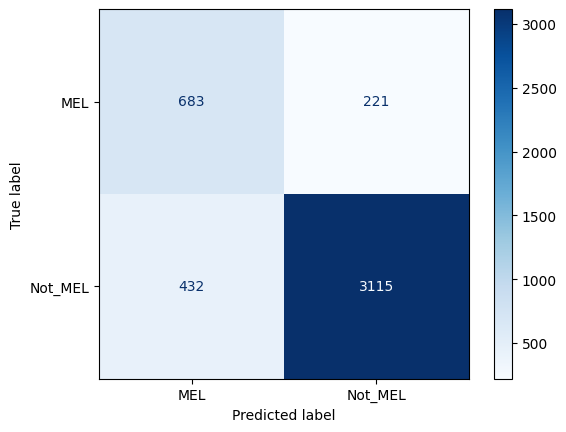

In [ ]:
import os
import torch
import torch.nn as nn
import timm
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets

# ==============================================================================
# SECTION 1: CONFIGURATION (EDIT THIS PART)
# ==============================================================================

# 1. Path to your trained model file
#    (Must be uploaded to your Colab session)
MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth' # <-- UPDATE THIS

# 2. Path to the single image you want to predict
#    (Must be uploaded to your Colab session)
#PATH_TO_EVALUATE = '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/MEL/ISIC_0000169.jpg' # <-- UPDATE THIS
PATH_TO_EVALUATE = '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/' # <-- UPDATE THIS
# 3. Class names in the EXACT order the model was trained on
CLASS_NAMES = ['MEL', 'Not_MEL']

# 4. Model and Data parameters (must match training)
IMG_SIZE = 300
BATCH_SIZE = 32

# ==============================================================================
# SECTION 2: PATH SANITY CHECK (DO NOT EDIT)
# ==============================================================================
print("--- PATH SANITY CHECK ---")
print(f"Checking path: '{PATH_TO_EVALUATE}'")

IS_DIR = False
IS_FILE = False

if not os.path.exists(PATH_TO_EVALUATE):
    print("\n❌ ERROR: This path does not exist in the current Colab environment.")
    print("TROUBLESHOOTING:")
    print("1. Check for typos in the path name.")
    print("2. Make sure you have uploaded the folder/file to Colab.")
    print("3. Use the file browser on the left to copy the correct path.")
else:
    if os.path.isdir(PATH_TO_EVALUATE):
        IS_DIR = True
        print("\n✅ SUCCESS: Path is a valid DIRECTORY.")
        print("Mode selected: Dataset Evaluation (will generate confusion matrix).")
        try:
            contents = os.listdir(PATH_TO_EVALUATE)
            if not contents:
                print("   - WARNING: The directory is empty.")
            else:
                print(f"   - Contents: {contents}")
                print("   - Ensure this directory contains sub-folders for each class (e.g., 'MEL', 'Not_MEL').")
        except Exception as e:
            print(f"   - Could not list directory contents: {e}")

    elif os.path.isfile(PATH_TO_EVALUATE):
        IS_FILE = True
        print("\n✅ SUCCESS: Path is a valid FILE.")
        print("Mode selected: Single Image Prediction.")
    else:
        print("\n❌ ERROR: The path exists but is not a regular file or directory.")
print("-------------------------\n")


# ==============================================================================
# SECTION 3: MODEL AND PREDICTION LOGIC (DO NOT EDIT)
# ==============================================================================

# --- Force all operations to CPU ---
device = torch.device("cpu")

# --- Define the Model Architecture ---
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SimpleClassifier, self).__init__()
        self.backbone = timm.create_model('efficientnet_b3', pretrained=False, num_classes=0, drop_rate=0.3)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))

# --- Main execution block ---
if __name__ == '__main__' and (IS_DIR or IS_FILE):
    # --- Load the Model ---
    print(f"Loading model from '{MODEL_PATH}'...")
    num_classes = len(CLASS_NAMES)
    model = SimpleClassifier(num_classes=num_classes)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device)
    model.eval()
    print("Model loaded successfully.")

    # --- Define Image Transformations ---
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # --- MODE 1: DATASET EVALUATION ---
    if IS_DIR:
        print(f"\n--- Running in Dataset Evaluation Mode on folder: '{PATH_TO_EVALUATE}' ---")
        dataset = datasets.ImageFolder(root=PATH_TO_EVALUATE, transform=transform)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in tqdm(loader, desc="Predicting Batches"):
                outputs = model(inputs.to(device))
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        print("\n--- Evaluation Complete ---")
        accuracy = accuracy_score(all_labels, all_preds)
        print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
        print("\nClassification Report:")
        print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
        print("\nConfusion Matrix:")
        cm = confusion_matrix(all_labels, all_preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        disp.plot(cmap=plt.cm.Blues)
        plt.show()

    # --- MODE 2: SINGLE IMAGE PREDICTION ---
    elif IS_FILE:
        print(f"\n--- Running in Single Image Prediction Mode on file: '{PATH_TO_EVALUATE}' ---")
        image = Image.open(PATH_TO_EVALUATE).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_tensor)
            probabilities = torch.nn.functional.softmax(output[0], dim=0)
            prediction_idx = torch.argmax(probabilities).item()
        predicted_class = CLASS_NAMES[prediction_idx]
        confidence = probabilities[prediction_idx].item()

        plt.figure(figsize=(6, 7))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%", fontsize=16)
        plt.show()

--- PATH SANITY CHECK ---
Checking path: '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/MEL/ISIC_0000146_downsampled.jpg'

✅ SUCCESS: Path is a valid FILE.
Mode selected: Single Image Prediction.
-------------------------

Loading model from '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth'...
Model loaded successfully.

--- Running in Single Image Prediction Mode on file: '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/MEL/ISIC_0000146_downsampled.jpg' ---


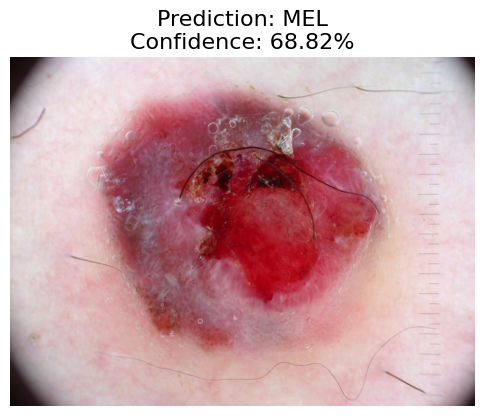

In [ ]:
import os
import torch
import torch.nn as nn
import timm
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from torch.utils.data import DataLoader
from torchvision import datasets

# =============================================================================
# SECTION 1: CONFIGURATION (EDIT THIS PART)
# =============================================================================

# 1. Path to your trained model file
MODEL_PATH = '/content/drive/MyDrive/SkinCancerProject/melanoma_binary_classifier_finetuned.pth'

# 2. Path to the single image OR folder you want to evaluate
#    (e.g., '/content/my_test_image.jpg' OR '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/')
PATH_TO_EVALUATE = '/content/drive/MyDrive/SkinCancerProject/MEL_vs_NotMEL_split_data/val/MEL/ISIC_0000146_downsampled.jpg' # <-- UPDATE THIS

# 3. Class names in the EXACT order the model was trained on
CLASS_NAMES = ['MEL', 'Not_MEL']

# 4. Model and Data parameters (must match training)
IMG_SIZE = 300
BATCH_SIZE = 32

# =============================================================================
# SECTION 2: PATH SANITY CHECK (DO NOT EDIT)
# =============================================================================
print("--- PATH SANITY CHECK ---")
print(f"Checking path: '{PATH_TO_EVALUATE}'")

IS_DIR = False
IS_FILE = False

if not os.path.exists(PATH_TO_EVALUATE):
    print("\n❌ ERROR: This path does not exist.")
    print("Please check the path and try again.")
else:
    if os.path.isdir(PATH_TO_EVALUATE):
        IS_DIR = True
        print("\n✅ SUCCESS: Path is a valid DIRECTORY.")
        print("Mode selected: Dataset Evaluation (will generate confusion matrix).")
    elif os.path.isfile(PATH_TO_EVALUATE):
        IS_FILE = True
        print("\n✅ SUCCESS: Path is a valid FILE.")
        print("Mode selected: Single Image Prediction.")
    else:
        print("\n❌ ERROR: The path exists but is not a regular file or directory.")
print("-------------------------\n")


# =============================================================================
# SECTION 3: MODEL AND PREDICTION LOGIC (DO NOT EDIT)
# =============================================================================

# --- Force all operations to CPU for easy inference ---
device = torch.device("cpu")

# --- Define the Model Architecture (must match your trained model) ---
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SimpleClassifier, self).__init__()
        # Ensure parameters match training (e.g., drop_rate)
        self.backbone = timm.create_model('efficientnet_b3', pretrained=False, num_classes=0, drop_rate=0.3)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))

# --- Main execution block ---
if __name__ == '__main__' and (IS_DIR or IS_FILE):
    # --- Load the Model ---
    print(f"Loading model from '{MODEL_PATH}'...")
    try:
        num_classes = len(CLASS_NAMES)
        model = SimpleClassifier(num_classes=num_classes)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.to(device)
        model.eval()
        print("Model loaded successfully.")
    except Exception as e:
        print(f"\n❌ ERROR: Failed to load model. {e}")
        print("Please ensure your MODEL_PATH is correct and the class definition matches.")

    # --- Define Image Transformations (must match your validation transforms) ---
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # --- MODE 1: DATASET EVALUATION ---
    if IS_DIR:
        print(f"\n--- Running in Dataset Evaluation Mode on folder: '{PATH_TO_EVALUATE}' ---")
        try:
            dataset = datasets.ImageFolder(root=PATH_TO_EVALUATE, transform=transform)
            loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

            # Verify classes match
            if dataset.classes != CLASS_NAMES:
                print(f"⚠️ WARNING: Class mismatch!")
                print(f"Expected: {CLASS_NAMES}")
                print(f"Found:    {dataset.classes}")

            all_preds, all_labels = [], []
            with torch.no_grad():
                for inputs, labels in tqdm(loader, desc="Predicting Batches"):
                    outputs = model(inputs.to(device))
                    _, predicted = torch.max(outputs, 1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            print("\n--- Evaluation Complete ---")
            accuracy = accuracy_score(all_labels, all_preds)
            print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
            print("\nClassification Report:")
            print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))
            print("\nConfusion Matrix:")
            cm = confusion_matrix(all_labels, all_preds)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
            disp.plot(cmap=plt.cm.Blues)
            plt.show()
        except Exception as e:
            print(f"\n❌ ERROR during dataset evaluation: {e}")
            print("Ensure your folder has sub-folders named 'MEL' and 'Not_MEL'.")


    # --- MODE 2: SINGLE IMAGE PREDICTION ---
    elif IS_FILE:
        print(f"\n--- Running in Single Image Prediction Mode on file: '{PATH_TO_EVALUATE}' ---")
        try:
            image = Image.open(PATH_TO_EVALUATE).convert("RGB")
            input_tensor = transform(image).unsqueeze(0).to(device)
            with torch.no_grad():
                output = model(input_tensor)
                probabilities = torch.nn.functional.softmax(output[0], dim=0)
                prediction_idx = torch.argmax(probabilities).item()

            predicted_class = CLASS_NAMES[prediction_idx]
            confidence = probabilities[prediction_idx].item()

            plt.figure(figsize=(6, 7))
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%", fontsize=16)
            plt.show()
        except Exception as e:
            print(f"\n❌ ERROR during single image prediction: {e}")